# Week 11 consolidated Bayesian optimisation notebook

This notebook presents Functions 1–8 in one systematic analytical record. Every function follows the same eleven-stage sequence below. UCB results are unevaluated proposals and are never appended as returned observations.

**Evidence used:** starter observations plus immutable-ledger returns through Week 10.

## Table of contents

1. Create week's_dataset by appending the previous output results
2. Extract the function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

# Function 1

Function 1 uses the verified evidence available before Week 11.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 1, 2, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [2]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
10,week_01,0.374540,0.950714,-1.560647e-117
11,week_02,0.536429,0.835362,1.674933e-36
12,week_03,0.614168,0.334143,-1.075594e-32
13,week_04,0.872626,0.321598,-2.466641e-107
14,week_05,0.897714,0.081699,7.651210e-239
15,week_06,0.222521,0.999673,6.131855e-211
16,week_07,0.350420,0.999543,-6.738616e-151
17,week_08,0.397837,0.919531,-1.772400e-96
18,week_09,0.421410,0.935804,-3.089424e-96


## 2. Extract the function

In [3]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 1: 2 input dimensions, 20 verified observations


## 3. Check shapes and missing values

In [4]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(20, 2)"
1,output shape,"(20,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [5]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,20.0,0.527762,0.237370,0.082507,3.685100e-01,4.789195e-01,6.953195e-01,8.977140e-01
x2,20.0,0.592222,0.342825,0.071186,3.073814e-01,7.072631e-01,8.898063e-01,9.996730e-01
output,20.0,-0.000180,0.000806,-0.003606,-5.222965e-92,-3.369308e-151,1.557464e-48,7.710875e-16


## 5. Plot the output trend

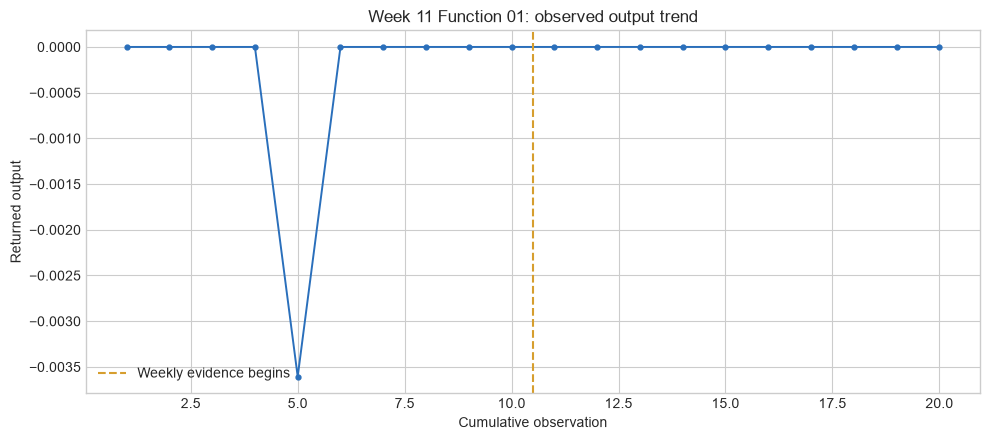

In [6]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

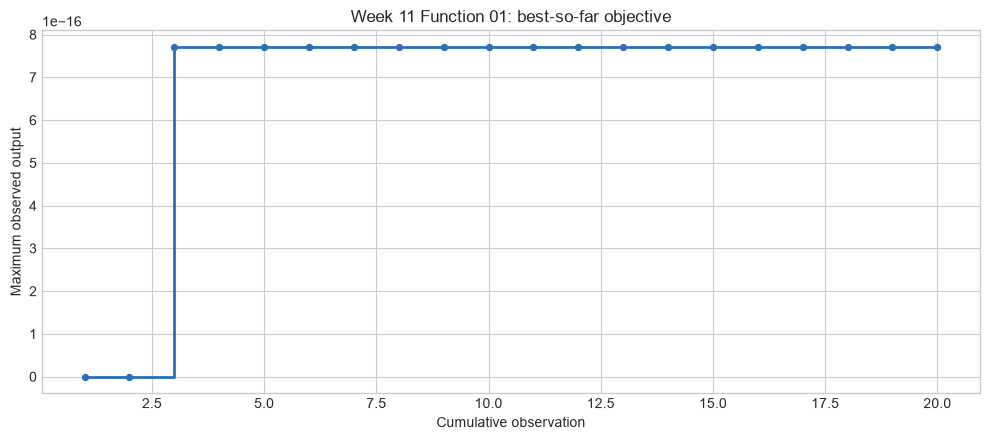

In [7]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [8]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,3,starter,0.731024,0.733,7.710875e-16


## 8. Plot the correlation heatmap

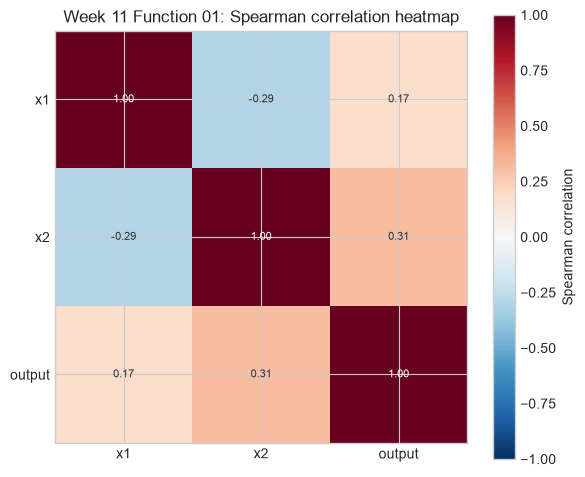

In [9]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

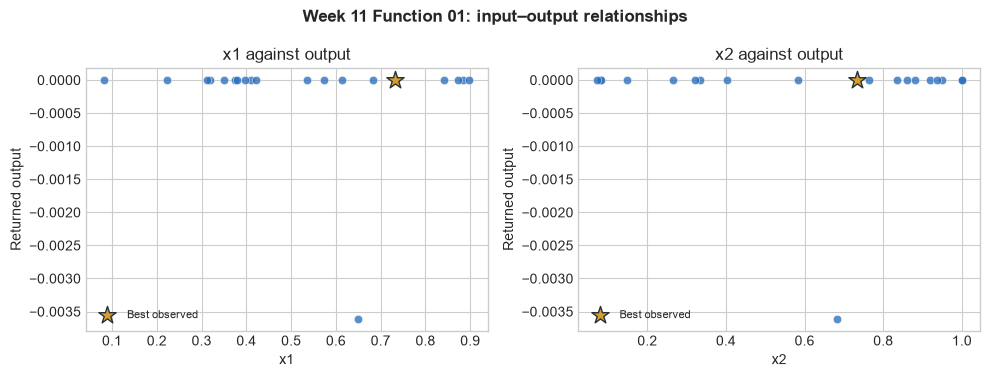

In [10]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [11]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.17**2 * Matern(length_scale=[10, 0.0454], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [12]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_1:0.932306-0.509534


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,11,1,2.0,0.932306,0.509534,-0.000043,0.000886,0.001728,proposed_not_evaluated


# Function 2

Function 2 uses the verified evidence available before Week 11.

In [13]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 2, 2, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [14]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
10,week_01,0.374540,0.950714,-0.031830
11,week_02,0.978752,0.932731,0.022667
12,week_03,0.000006,0.334143,0.048684
13,week_04,0.197553,0.808683,0.038775
14,week_05,0.555332,0.360931,0.220781
15,week_06,0.473151,0.950706,0.160532
16,week_07,0.009675,0.999881,0.048714
17,week_08,0.314242,0.973527,0.072764
18,week_09,0.995366,0.102732,0.049406


## 2. Extract the function

In [15]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 2: 2 input dimensions, 20 verified observations


## 3. Check shapes and missing values

In [16]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(20, 2)"
1,output shape,"(20,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [17]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,20.0,0.480643,0.294990,0.000006,0.325401,0.446407,0.675009,0.995366
x2,20.0,0.614565,0.346222,0.028698,0.323221,0.741547,0.937225,0.999881
output,20.0,0.148201,0.190769,-0.065624,0.025868,0.049060,0.226740,0.611205


## 5. Plot the output trend

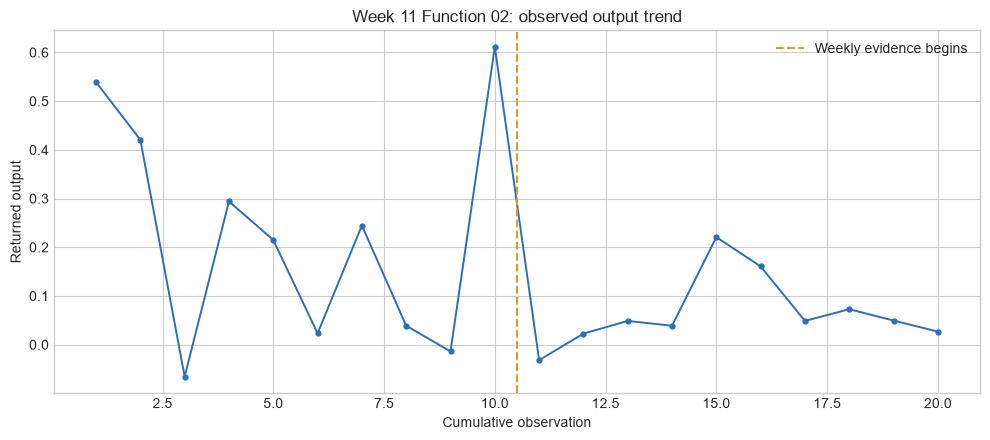

In [18]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

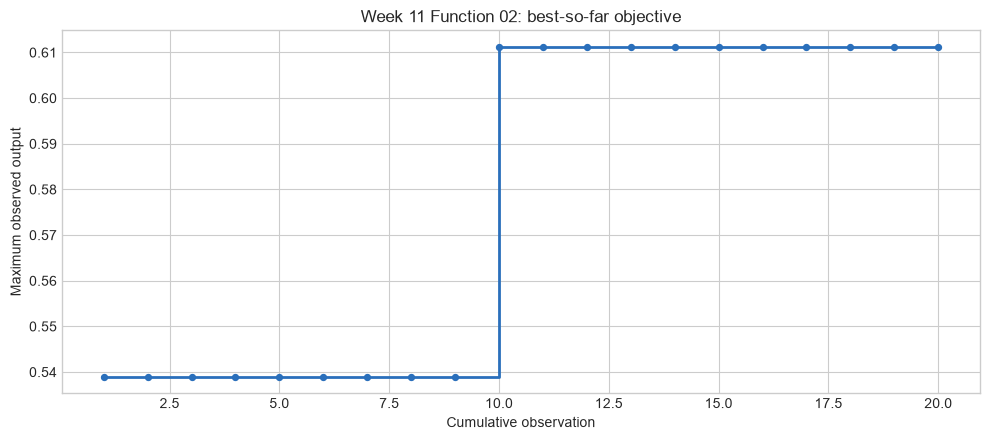

In [19]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [20]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,10,starter,0.702637,0.926564,0.611205


## 8. Plot the correlation heatmap

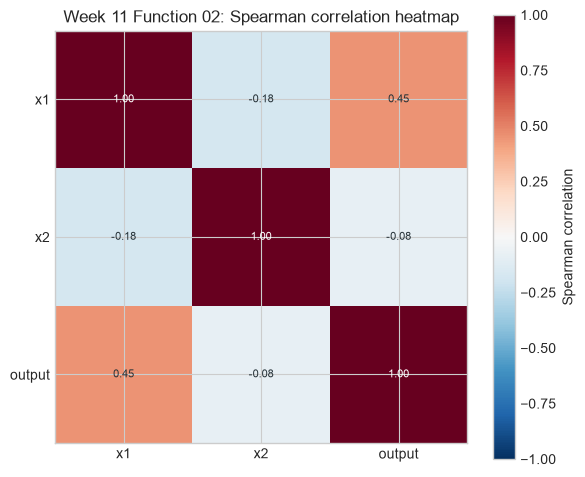

In [21]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

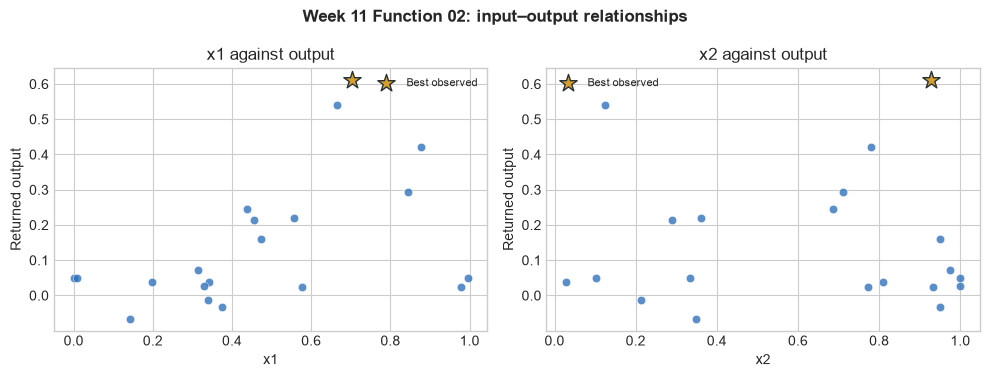

In [22]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [23]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1**2 * Matern(length_scale=[0.0477, 10], nu=2.5) + WhiteKernel(noise_level=0.0209)
Training R²: 0.9966


## 11. Apply UCB to generate the next query point

In [24]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_2:0.689399-0.099088


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,11,2,2.0,0.689399,0.099088,0.614964,0.051496,0.717957,proposed_not_evaluated


# Function 3

Function 3 uses the verified evidence available before Week 11.

In [25]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 3, 3, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [26]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,output
observation,,,,,
15,week_01,0.444444,0.666666,0.333333,-0.040908
16,week_02,0.657452,0.998464,0.817253,-0.089875
17,week_03,0.670026,0.057881,0.658241,-0.183239
18,week_04,0.650132,0.218327,0.110542,-0.082513
19,week_05,0.522711,0.090769,0.451242,-0.057397
20,week_06,0.418776,0.420613,0.695421,-0.117005
21,week_07,0.427731,0.669810,0.343678,-0.047183
22,week_08,0.457347,0.664022,0.295993,-0.077413
23,week_09,0.449035,0.664262,0.290384,-0.081893


## 2. Extract the function

In [27]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 3: 3 input dimensions, 25 verified observations


## 3. Check shapes and missing values

In [28]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(25, 3)"
1,output shape,"(25,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [29]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,25.0,0.451217,0.225698,0.046809,0.242114,0.449035,0.645503,0.965995
x2,25.0,0.514996,0.257519,0.057881,0.297825,0.611593,0.669810,0.998464
x3,25.0,0.414510,0.256234,0.066089,0.248737,0.333333,0.566829,0.990882
output,25.0,-0.097251,0.072572,-0.398926,-0.112122,-0.087963,-0.048008,-0.034835


## 5. Plot the output trend

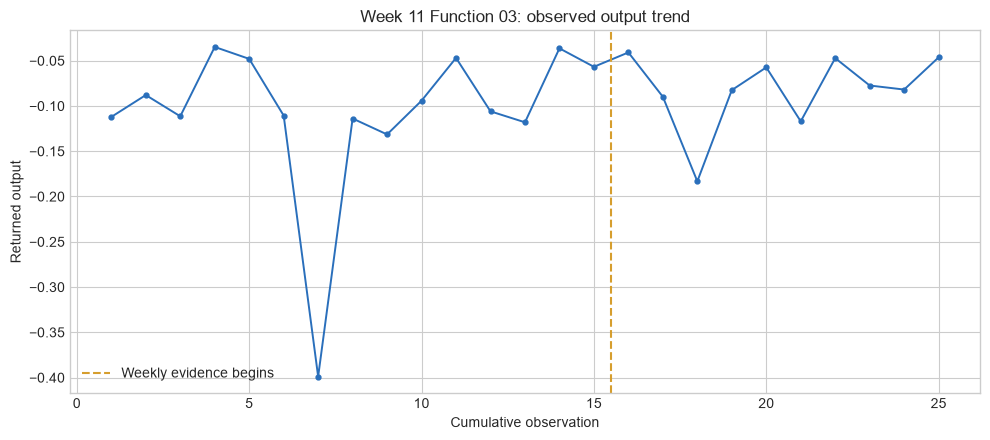

In [30]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

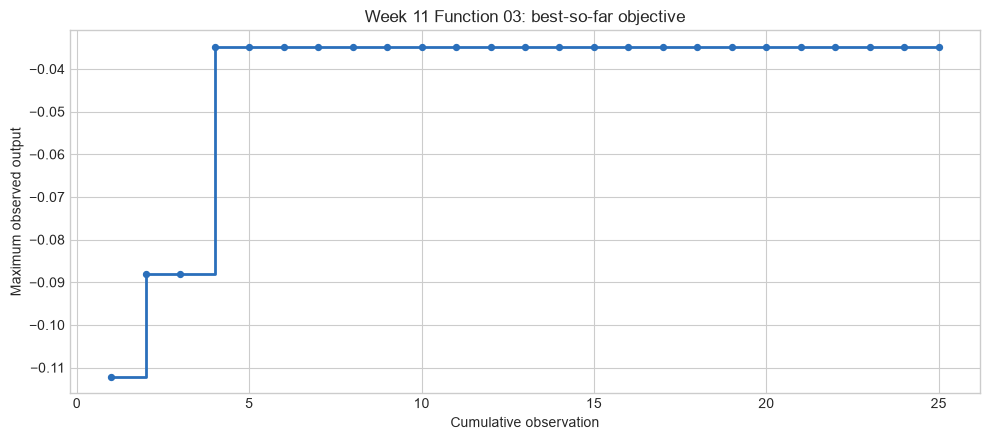

In [31]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [32]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,output
0,4,starter,0.492581,0.611593,0.340176,-0.034835


## 8. Plot the correlation heatmap

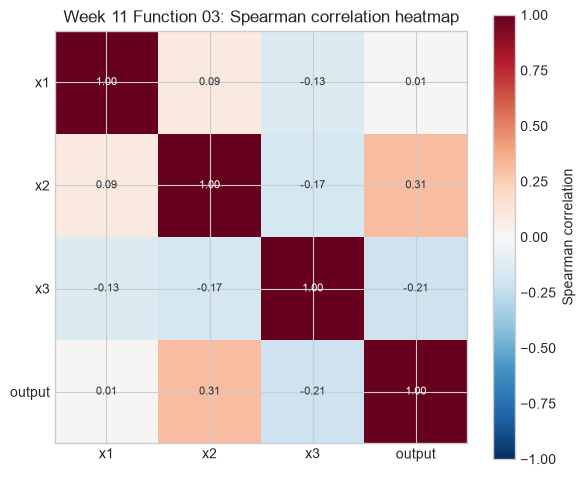

In [33]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

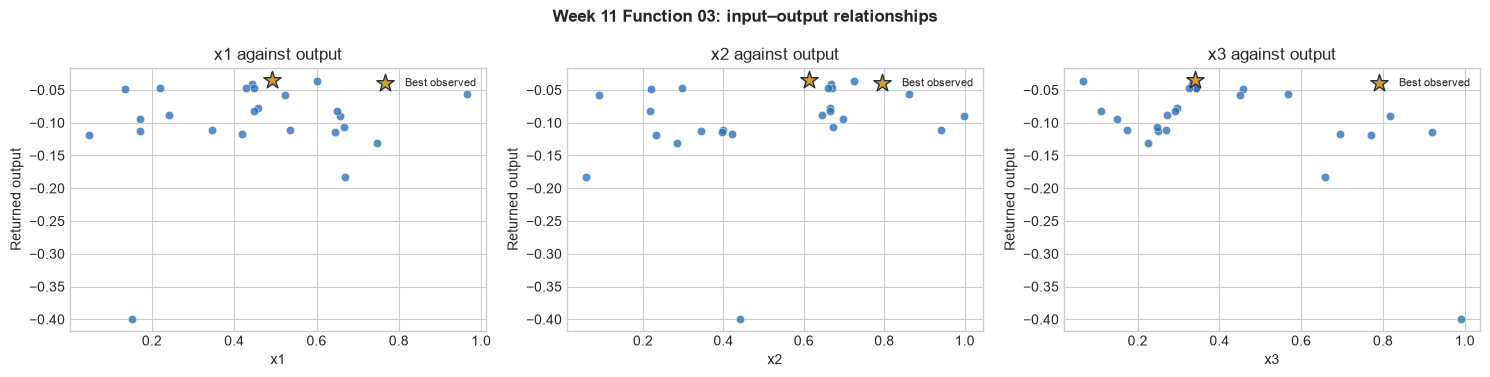

In [34]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [35]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.36**2 * Matern(length_scale=[2.44, 1.43, 0.071], nu=2.5) + WhiteKernel(noise_level=1.01e-06)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [36]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_3:0.073069-0.118664-0.000611


,week,function,kappa,x1,x2,x3,predicted_mean,predicted_std,ucb_score,status
0,11,3,2.0,0.073069,0.118664,0.000611,-0.062313,0.082468,0.102623,proposed_not_evaluated


# Function 4

Function 4 uses the verified evidence available before Week 11.

In [37]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 4, 4, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [38]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
30,week_01,0.555555,0.444444,0.222222,0.111111,-8.727516
31,week_02,0.006280,0.281840,0.932013,0.960202,-31.735358
32,week_03,0.394519,0.361122,0.256803,0.461856,-1.981075
33,week_04,0.715715,0.504442,0.275065,0.552962,-9.312812
34,week_05,0.713766,0.198601,0.014095,0.068347,-17.926307
35,week_06,0.753422,0.441826,0.942545,0.489846,-20.879363
36,week_07,0.096005,0.028299,0.033322,0.077327,-20.195854
37,week_08,0.046009,0.778273,0.979511,0.088488,-28.736323
38,week_09,0.889493,0.002958,0.445975,0.774547,-23.422803


## 2. Extract the function

In [39]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 4: 4 input dimensions, 40 verified observations


## 3. Check shapes and missing values

In [40]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(40, 4)"
1,output shape,"(40,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [41]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,40.0,0.526122,0.298621,0.006280,0.250137,0.582847,0.748382,0.985622
x2,40.0,0.446753,0.294437,0.002958,0.160877,0.488034,0.681607,0.919592
x3,40.0,0.452953,0.295004,0.014095,0.214464,0.432316,0.715852,0.979511
x4,40.0,0.446005,0.302921,0.032616,0.127802,0.475851,0.735386,0.999483
output,40.0,-17.380019,7.599507,-32.625660,-22.366073,-16.280462,-12.726746,-1.981075


## 5. Plot the output trend

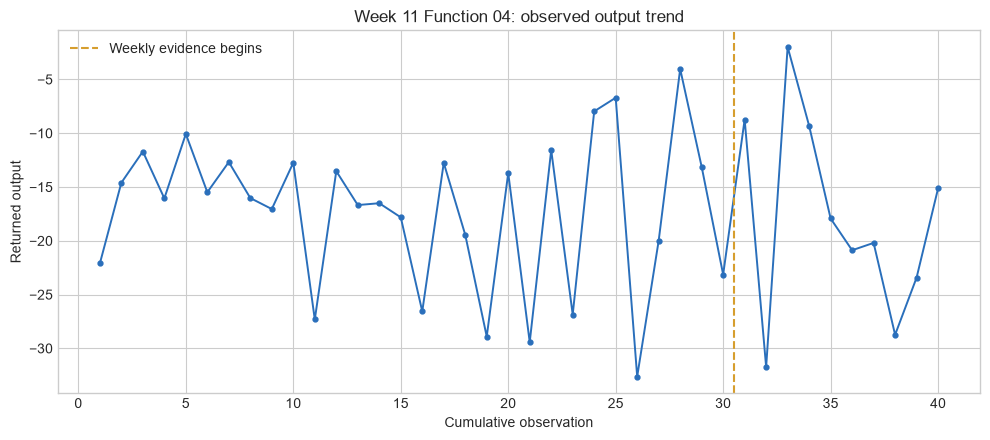

In [42]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

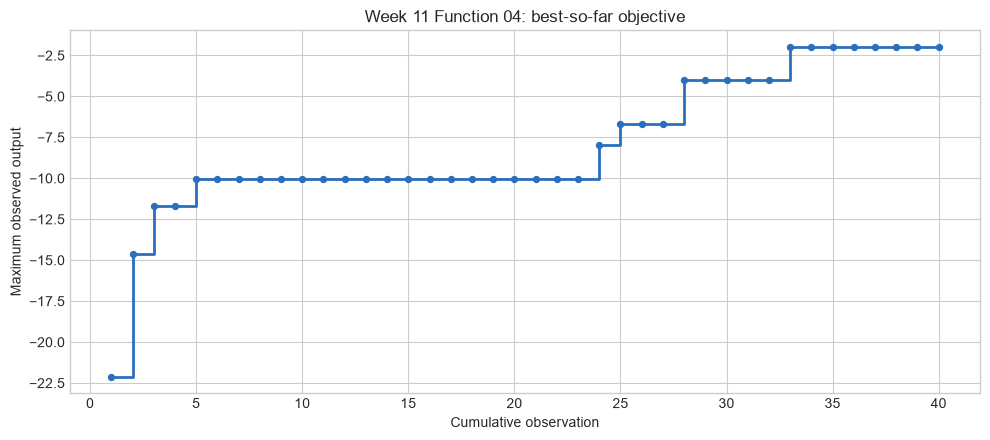

In [43]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [44]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,33,week_03,0.394519,0.361122,0.256803,0.461856,-1.981075


## 8. Plot the correlation heatmap

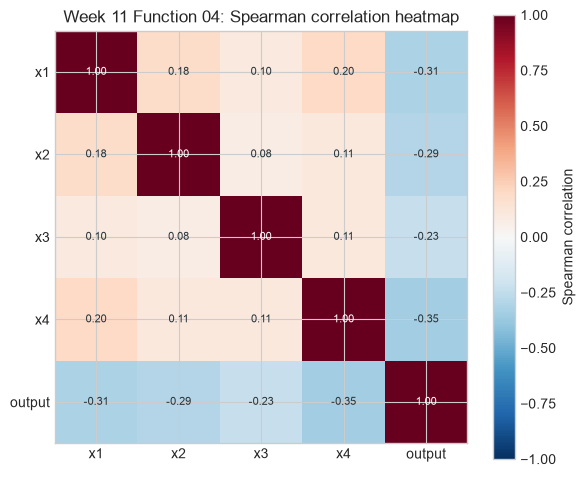

In [45]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

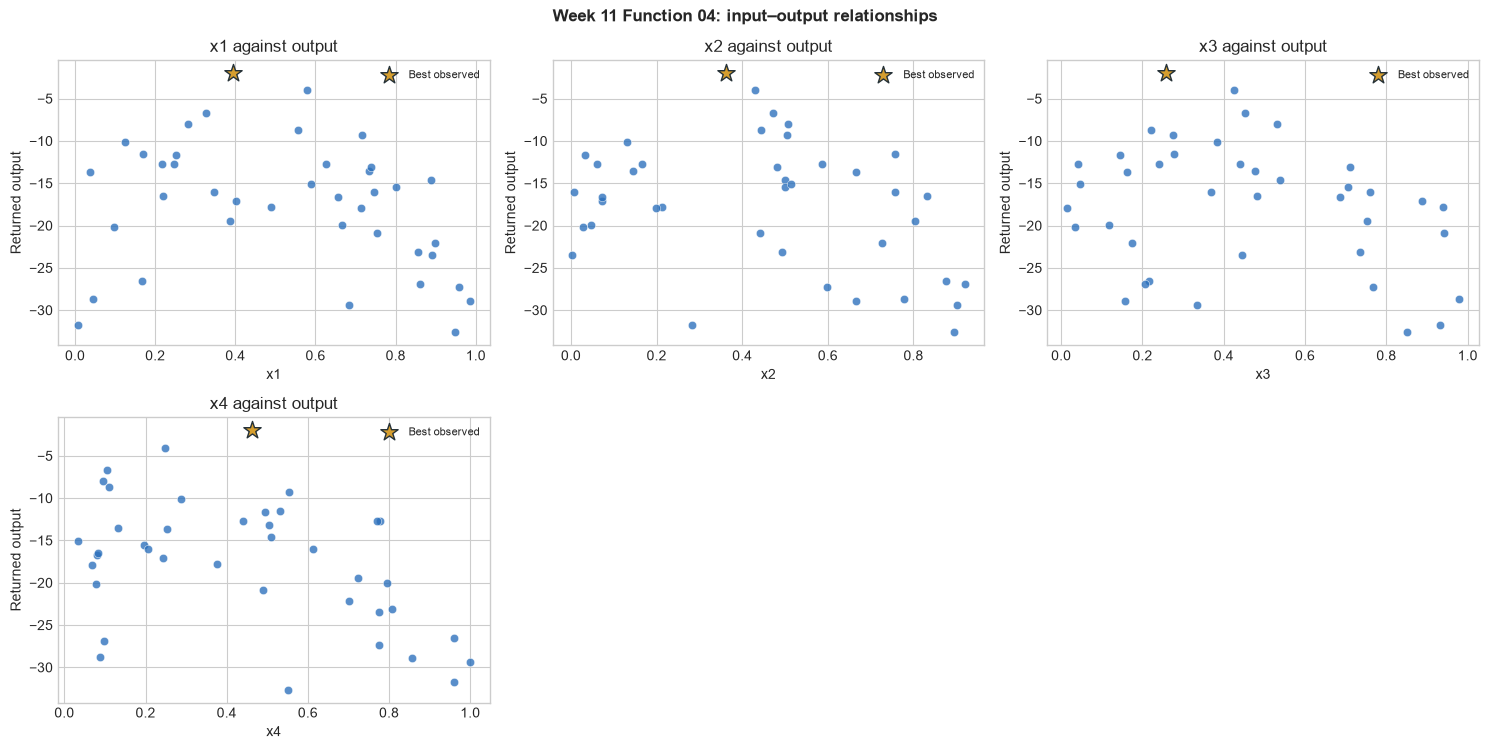

In [46]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [47]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 5.75**2 * Matern(length_scale=[2.27, 2.27, 2.39, 2.37], nu=2.5) + WhiteKernel(noise_level=0.00178)
Training R²: 0.9998


## 11. Apply UCB to generate the next query point

In [48]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_4:0.435872-0.488451-0.382382-0.376813


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,11,4,2.0,0.435872,0.488451,0.382382,0.376813,-1.812605,0.527353,-0.7579,proposed_not_evaluated


# Function 5

Function 5 uses the verified evidence available before Week 11.

In [49]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 5, 4, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [50]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
20,week_01,0.224189,0.846480,0.879484,0.878515,1088.853511
21,week_02,0.255841,0.841692,0.888984,0.860260,1035.634146
22,week_03,0.255842,0.841692,0.888985,0.860266,1035.664748
23,week_04,0.000000,0.000000,0.000000,0.000000,163.122500
24,week_05,0.754614,0.504566,0.432986,0.307039,0.940116
25,week_06,0.654981,0.602894,0.898891,0.589622,281.911573
26,week_07,0.000000,0.000000,0.000000,0.000000,163.122500
27,week_08,0.081230,0.992582,0.156202,0.988421,1465.512192
28,week_09,0.319924,0.675406,0.431628,1.000000,430.803125


## 2. Extract the function

In [51]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 5: 4 input dimensions, 30 verified observations


## 3. Check shapes and missing values

In [52]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(30, 4)"
1,output shape,"(30,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [53]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,30.0,0.391997,0.255875,0.00000,0.199633,0.353919,0.637229,0.836478
x2,30.0,0.539840,0.304440,0.00000,0.318219,0.616459,0.814553,0.992582
x3,30.0,0.494287,0.289840,0.00000,0.279134,0.456289,0.719676,0.898891
x4,30.0,0.545552,0.343459,0.00000,0.219648,0.524832,0.860264,1.000000
output,30.0,337.187951,457.854239,0.11294,32.945456,94.650503,412.054048,1465.512192


## 5. Plot the output trend

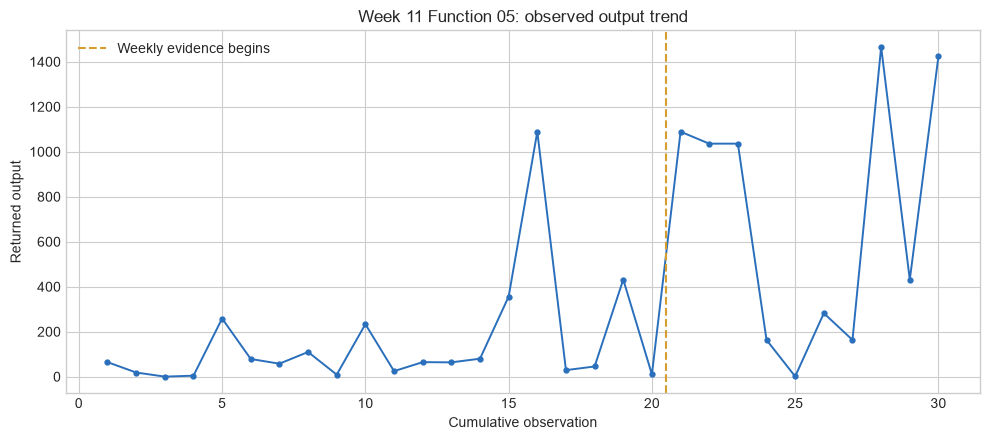

In [54]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

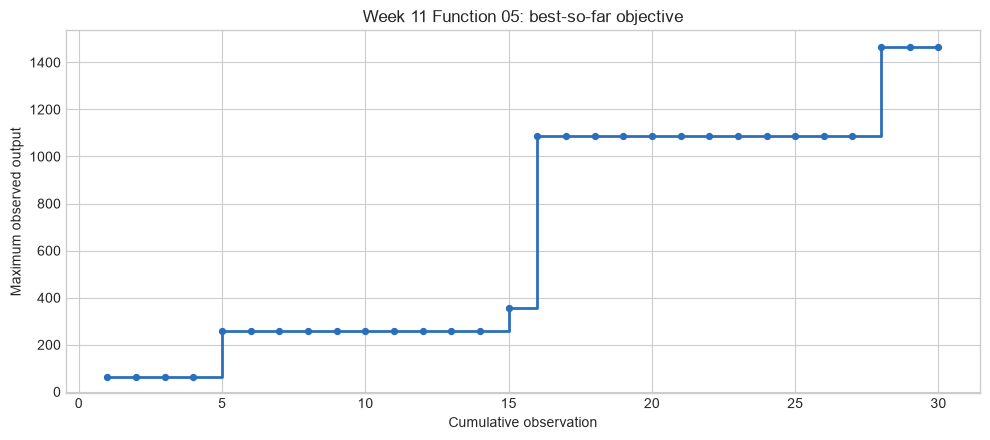

In [55]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [56]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,28,week_08,0.08123,0.992582,0.156202,0.988421,1465.512192


## 8. Plot the correlation heatmap

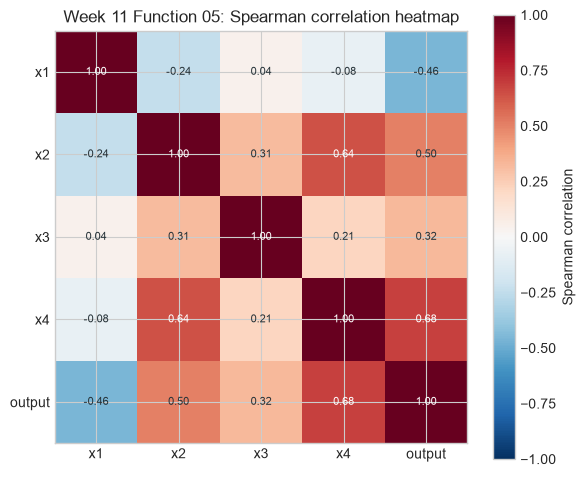

In [57]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

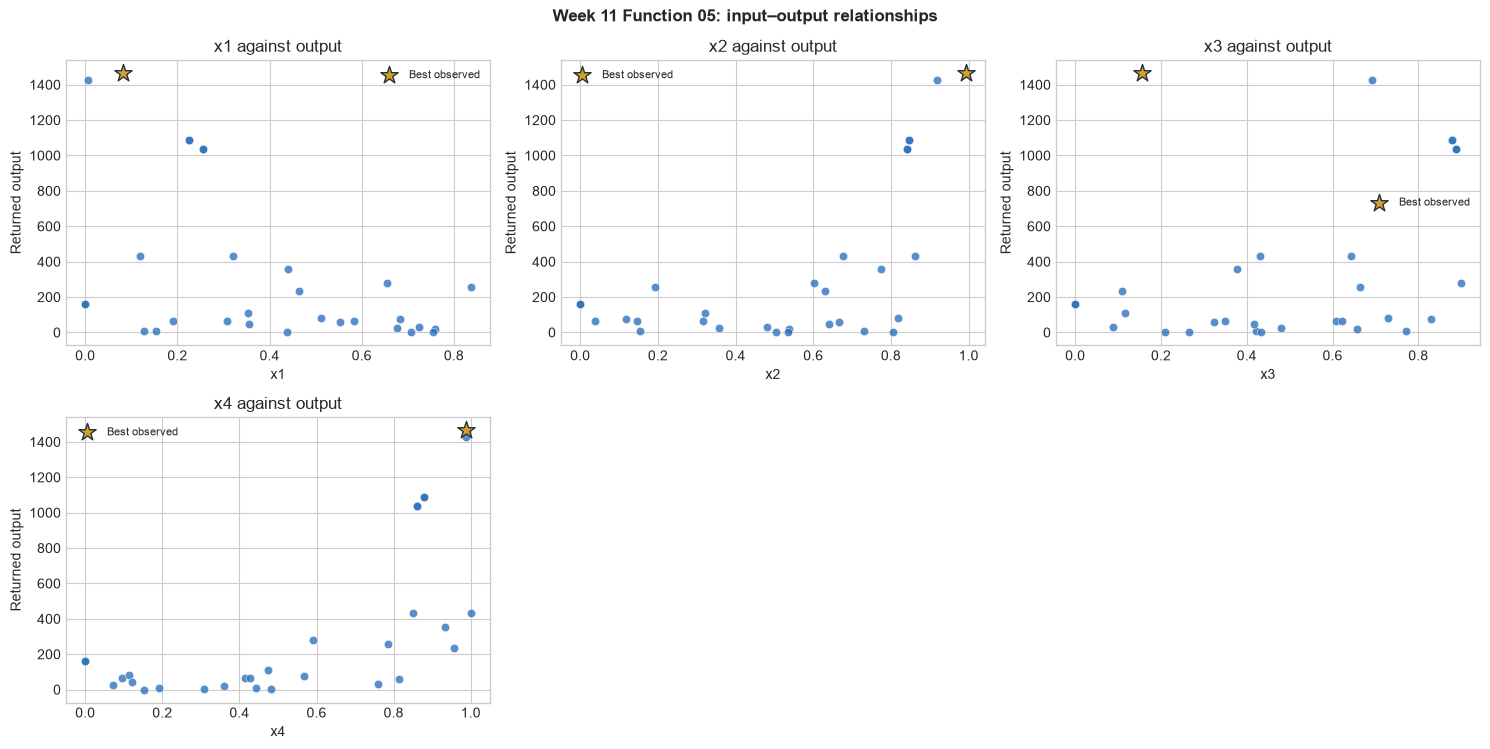

In [58]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [59]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.858**2 * Matern(length_scale=[0.203, 2.96, 10, 0.12], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [60]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_5:0.088941-0.011935-0.122394-0.974603


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,11,5,2.0,0.088941,0.011935,0.122394,0.974603,1333.038234,156.116839,1645.271912,proposed_not_evaluated


# Function 6

Function 6 uses the verified evidence available before Week 11.

In [61]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 6, 5, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [62]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,output
observation,,,,,,,
20,week_01,0.728186,0.154693,0.732552,0.693997,0.564013,-1.152035
21,week_02,0.433654,0.486678,0.282753,0.972905,0.323321,-0.878241
22,week_03,0.495070,0.097152,0.672921,0.000007,0.351268,-1.339542
23,week_04,0.973181,0.022807,0.714484,0.145453,0.974790,-2.437508
24,week_05,0.824244,0.022732,0.960907,0.041715,0.897560,-2.529369
25,week_06,0.781770,0.192076,0.805757,0.695733,0.565940,-1.312540
26,week_07,0.683830,0.035248,0.777884,0.740721,0.629310,-1.287089
27,week_08,0.994993,0.316819,0.508801,0.557706,0.579403,-1.479452
28,week_09,0.711755,0.175670,0.738396,0.689597,0.562717,-1.171713


## 2. Extract the function

In [63]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 6: 5 input dimensions, 30 verified observations


## 3. Check shapes and missing values

In [64]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(30, 5)"
1,output shape,"(30,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [65]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,30.0,0.614501,0.282237,0.021735,0.435077,0.719971,0.784439,0.994993
x2,30.0,0.430243,0.308975,0.022732,0.159937,0.324311,0.739984,0.931871
x3,30.0,0.541316,0.294581,0.016523,0.359334,0.657517,0.736935,0.978806
x4,30.0,0.526033,0.292506,0.000007,0.274092,0.621691,0.702683,0.972905
x5,30.0,0.484475,0.279891,0.004911,0.285992,0.563365,0.625723,0.974790
output,30.0,-1.498146,0.480500,-2.571170,-1.700504,-1.348112,-1.215913,-0.714265


## 5. Plot the output trend

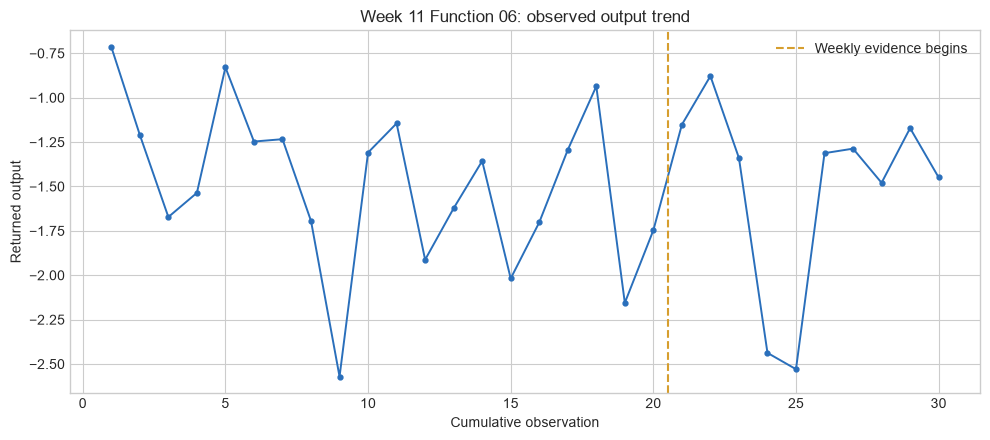

In [66]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

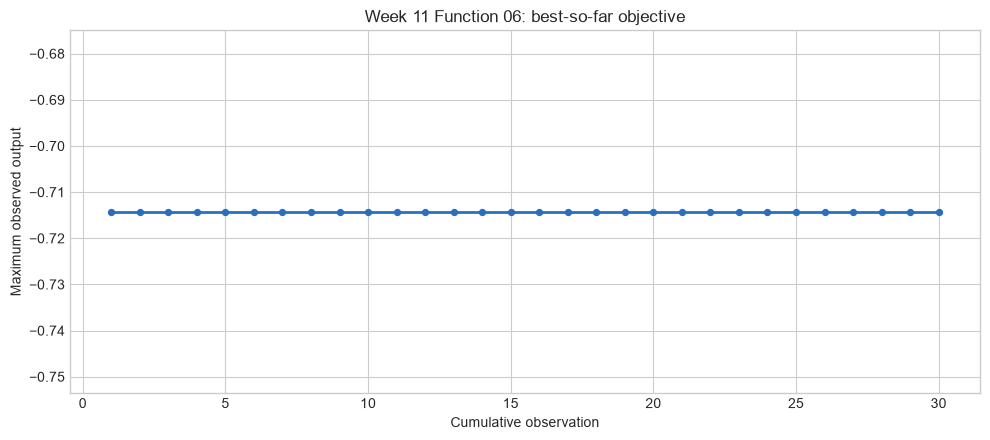

In [67]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [68]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,output
0,1,starter,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


## 8. Plot the correlation heatmap

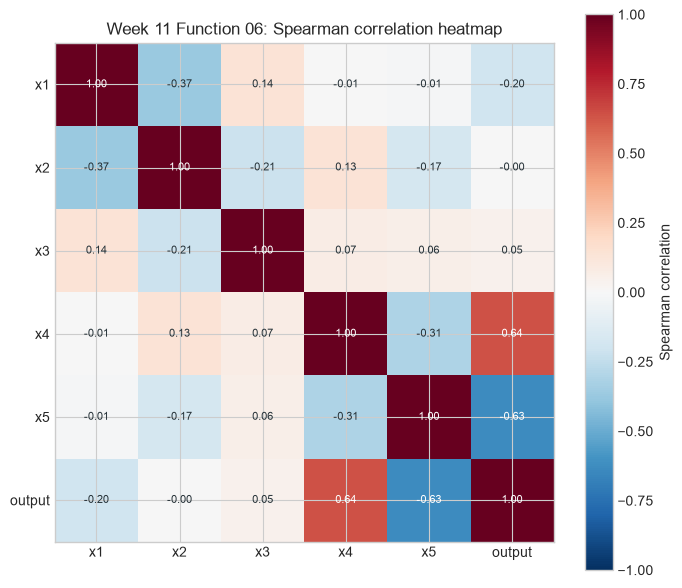

In [69]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

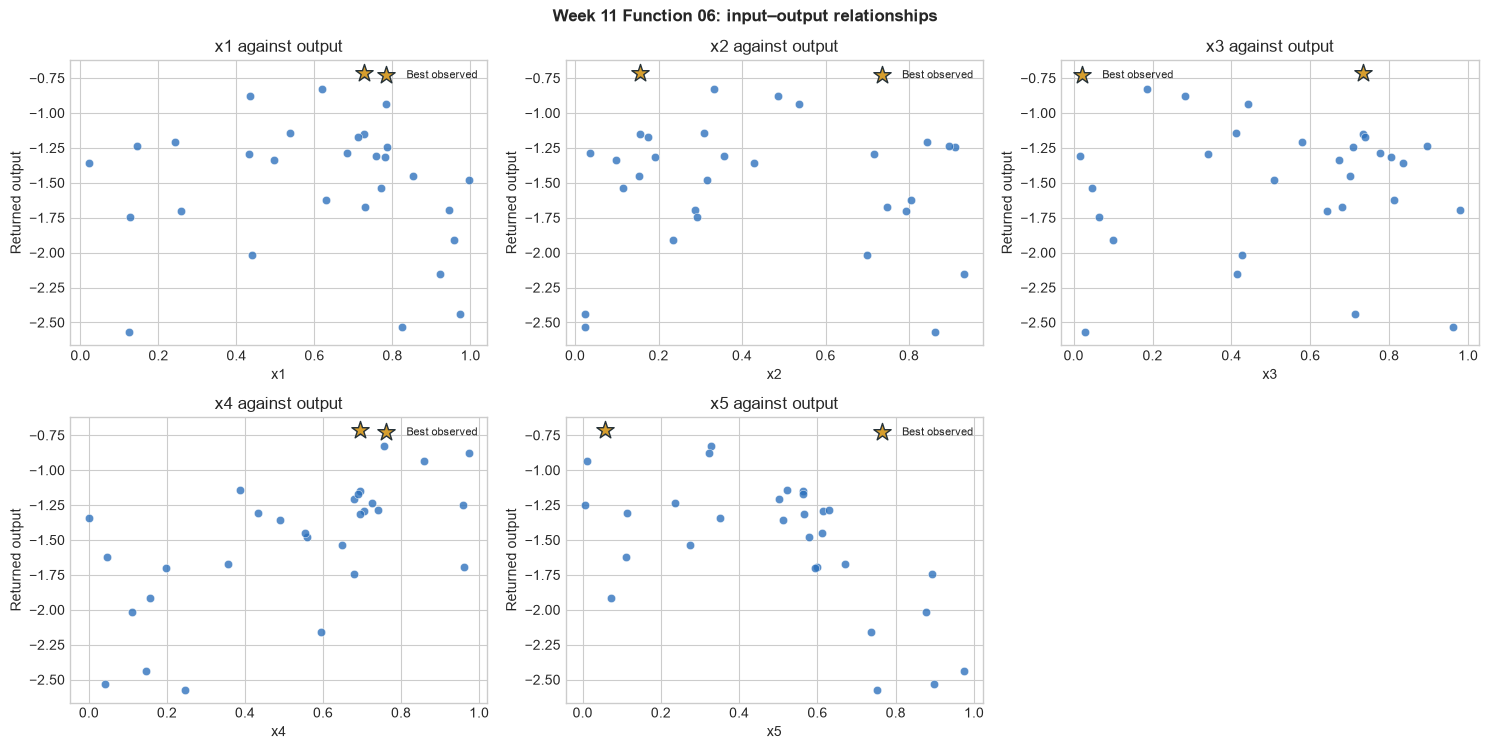

In [70]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [71]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.56**2 * Matern(length_scale=[1.89, 0.467, 0.916, 1.32, 0.752], nu=2.5) + WhiteKernel(noise_level=1.26e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [72]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_6:0.030018-0.163226-0.626006-0.968135-0.168375


,week,function,kappa,x1,x2,x3,x4,x5,predicted_mean,predicted_std,ucb_score,status
0,11,6,2.0,0.030018,0.163226,0.626006,0.968135,0.168375,-0.477989,0.280933,0.083878,proposed_not_evaluated


# Function 7

Function 7 uses the verified evidence available before Week 11.

In [73]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 7, 6, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [74]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,output
observation,,,,,,,,
30,week_01,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,1.051015
31,week_02,0.243848,0.900100,0.696978,0.193630,0.374149,0.826324,0.308765
32,week_03,0.143585,0.302559,0.571101,0.194533,0.395561,0.815792,2.149905
33,week_04,0.045103,0.016167,0.773003,0.156031,0.147073,0.616114,1.208733
34,week_05,0.025337,0.910075,0.727790,0.075231,0.386516,0.492629,0.190783
35,week_06,0.042873,0.466831,0.379623,0.207090,0.367754,0.515646,1.611967
36,week_07,0.121173,0.544849,0.282921,0.037758,0.374065,0.591179,0.899499
37,week_08,0.016174,0.558963,0.348588,0.050763,0.417748,0.644030,0.846180
38,week_09,0.018603,0.530937,0.376818,0.094048,0.443567,0.614974,1.009894


## 2. Extract the function

In [75]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 7: 6 input dimensions, 40 verified observations


## 3. Check shapes and missing values

In [76]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(40, 6)"
1,output shape,"(40,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [77]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,40.0,0.403370,0.324763,0.016174,0.103293,0.296217,0.723533,0.942451
x2,40.0,0.431469,0.258862,0.011813,0.243025,0.465863,0.572986,0.924694
x3,40.0,0.412097,0.288762,0.003635,0.217435,0.354342,0.684254,0.924571
x4,40.0,0.415728,0.319767,0.037758,0.154201,0.271793,0.737994,0.961017
x5,40.0,0.445019,0.277300,0.014944,0.242170,0.415690,0.685195,0.998655
x6,40.0,0.524167,0.247956,0.051100,0.357071,0.615544,0.697302,0.951014
output,40.0,0.417764,0.515957,0.002701,0.030509,0.198546,0.627430,2.149905


## 5. Plot the output trend

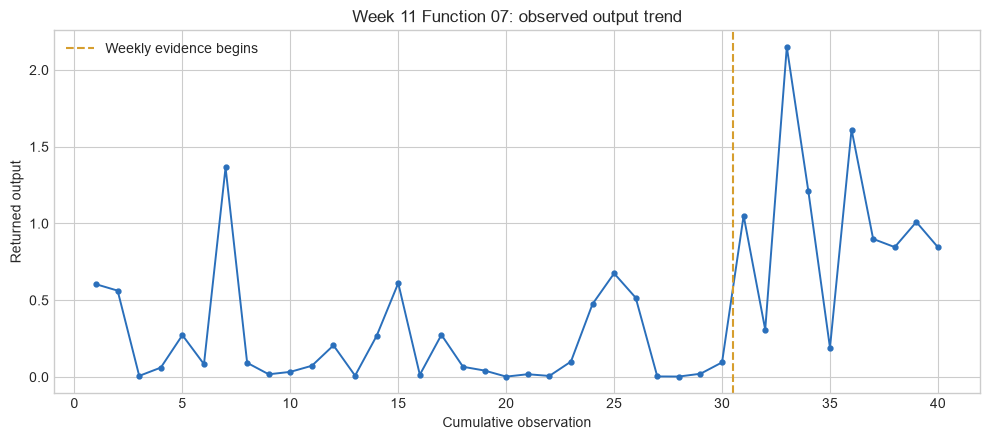

In [78]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

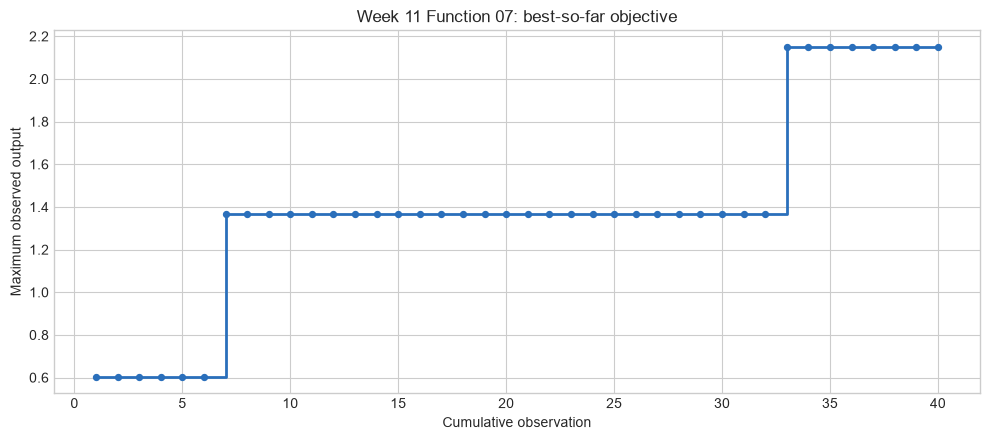

In [79]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [80]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,output
0,33,week_03,0.143585,0.302559,0.571101,0.194533,0.395561,0.815792,2.149905


## 8. Plot the correlation heatmap

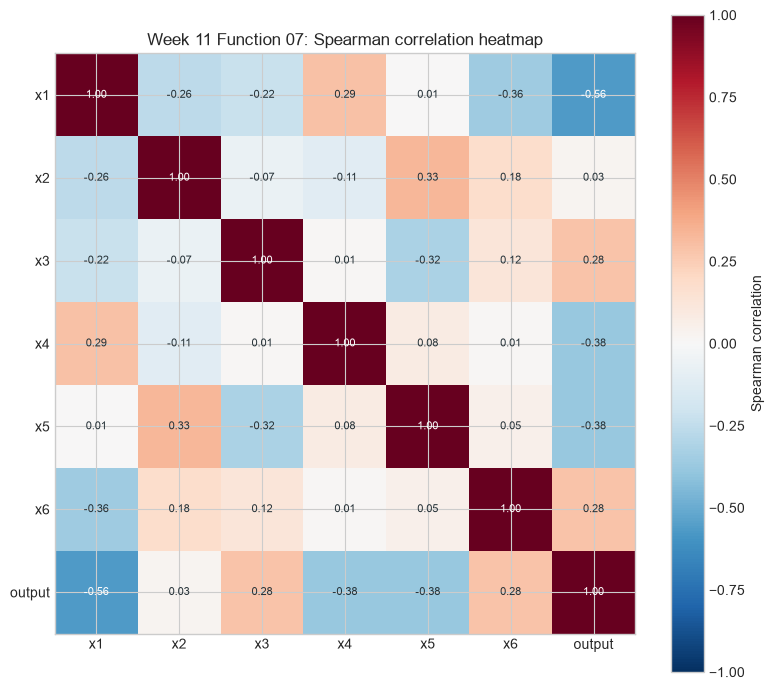

In [81]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

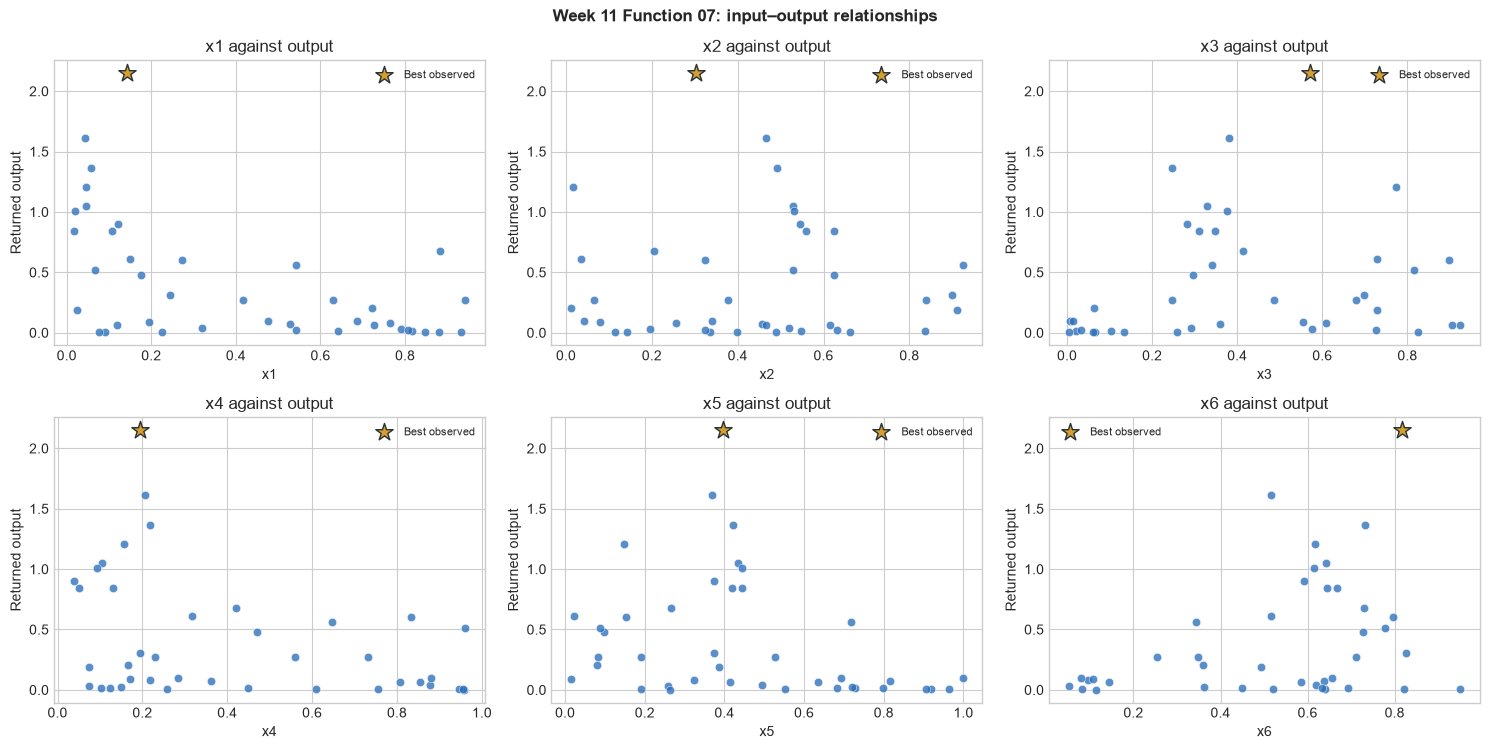

In [82]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [83]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.946**2 * Matern(length_scale=[0.708, 0.352, 10, 0.433, 0.318, 0.715], nu=2.5) + WhiteKernel(noise_level=2.48e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [84]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_7:0.126865-0.215304-0.911449-0.279216-0.328162-0.824801


,week,function,kappa,x1,x2,x3,x4,x5,x6,predicted_mean,predicted_std,ucb_score,status
0,11,7,2.0,0.126865,0.215304,0.911449,0.279216,0.328162,0.824801,2.175183,0.159655,2.494494,proposed_not_evaluated


# Function 8

Function 8 uses the verified evidence available before Week 11.

In [85]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 11, 8, 8, 10
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [86]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,x7,x8,output
observation,,,,,,,,,,
40,week_01,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.352588,9.815709
41,week_02,0.163160,0.184786,0.152644,0.083802,0.999322,0.544113,0.184124,0.123846,9.939904
42,week_03,0.088894,0.525132,0.030986,0.992538,0.870819,0.217060,0.011239,0.447691,8.963604
43,week_04,0.356502,0.157574,0.172997,0.610561,0.106477,0.260297,0.411421,0.904740,9.254064
44,week_05,0.110992,0.022977,0.255313,0.963757,0.895383,0.716713,0.030436,0.083412,9.138609
45,week_06,0.115956,0.821931,0.587418,0.022809,0.440260,0.965550,0.368459,0.301774,8.557034
46,week_07,0.006802,0.833571,0.147083,0.461921,0.263530,0.887722,0.724982,0.315234,8.563639
47,week_08,0.712683,0.197193,0.129585,0.337018,0.771044,0.106613,0.229839,0.008464,9.020091
48,week_09,0.321258,0.232284,0.021301,0.000000,0.895967,0.249315,0.054463,0.073967,9.699892


## 2. Extract the function

In [87]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 8: 8 input dimensions, 50 verified observations


## 3. Check shapes and missing values

In [88]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(50, 8)"
1,output shape,"(50,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [89]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,50.0,0.481623,0.312038,0.006802,0.176614,0.476658,0.776238,0.985945
x2,50.0,0.445699,0.307005,0.003419,0.172348,0.470746,0.688062,0.973980
x3,50.0,0.446931,0.296241,0.021301,0.222696,0.379438,0.714520,0.998885
x4,50.0,0.416946,0.286402,0.000000,0.137653,0.438626,0.656450,0.992538
x5,50.0,0.512699,0.296622,0.009649,0.251514,0.491909,0.763413,0.999322
x6,50.0,0.453079,0.285066,0.022113,0.234401,0.397824,0.707594,0.990244
x7,50.0,0.508218,0.287358,0.011239,0.241859,0.552563,0.754113,0.992914
x8,50.0,0.459840,0.291340,0.008464,0.198253,0.447265,0.705659,0.988755
output,50.0,8.098744,1.050221,5.592193,7.340347,8.219023,8.973316,9.939904


## 5. Plot the output trend

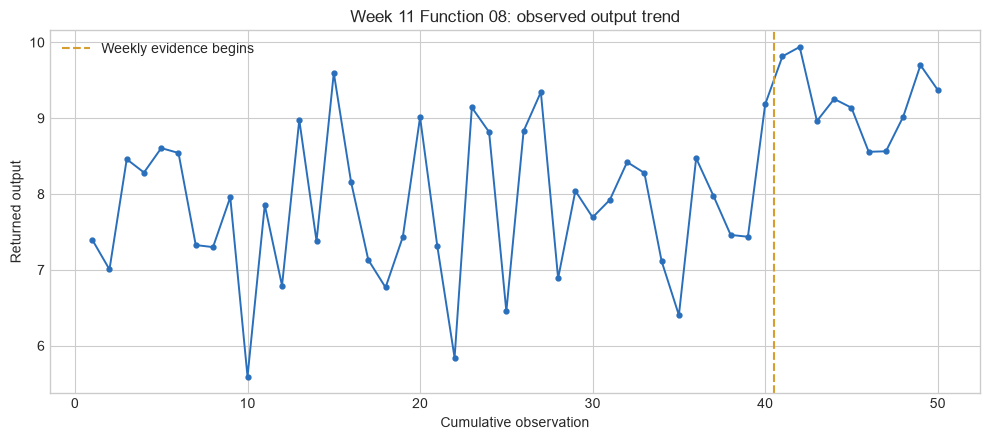

In [90]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

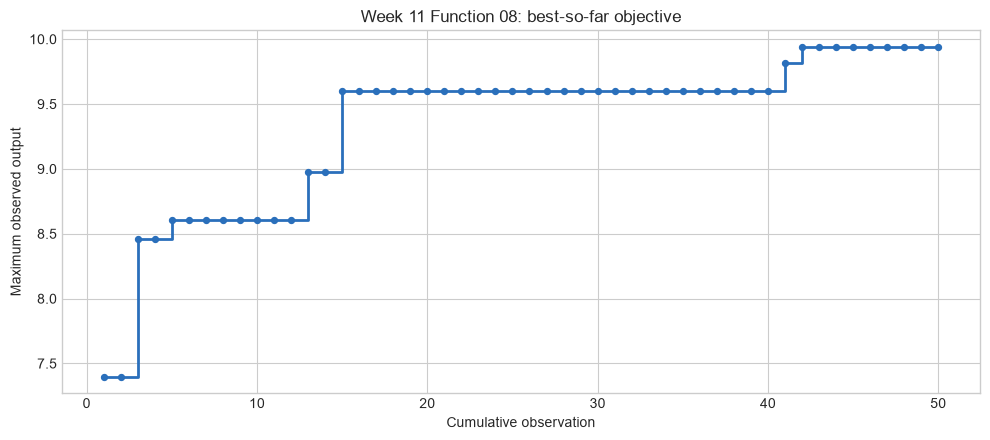

In [91]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [92]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,x7,x8,output
0,42,week_02,0.16316,0.184786,0.152644,0.083802,0.999322,0.544113,0.184124,0.123846,9.939904


## 8. Plot the correlation heatmap

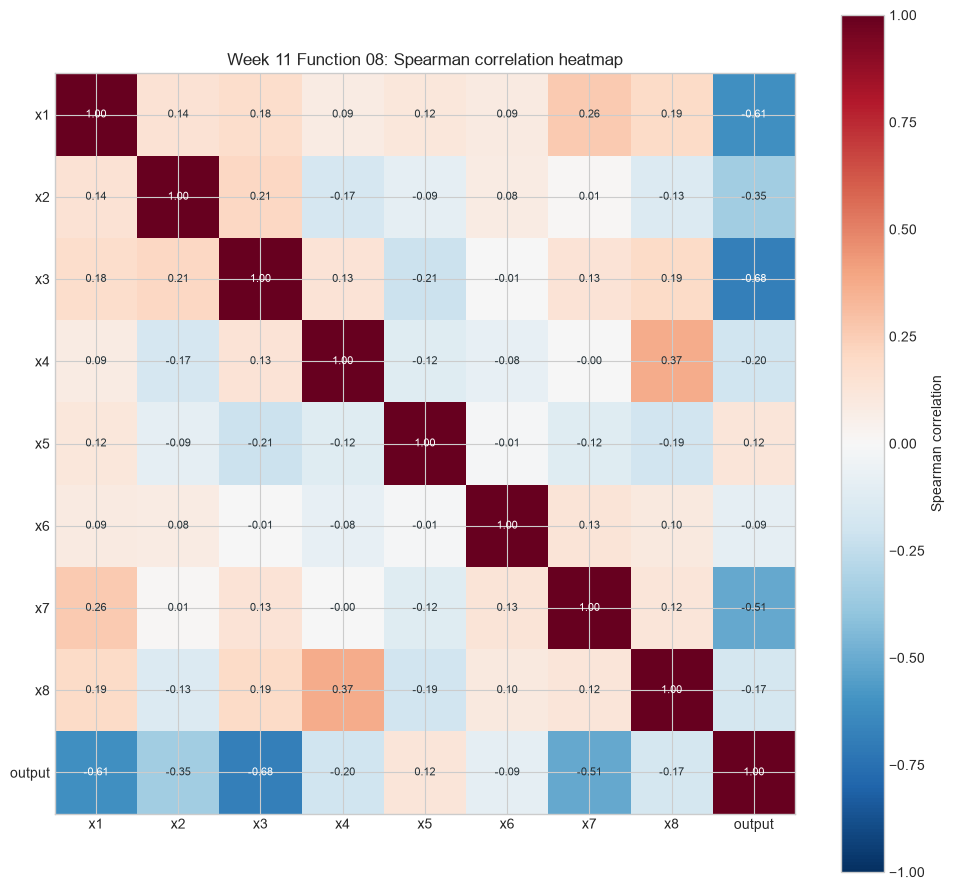

In [93]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

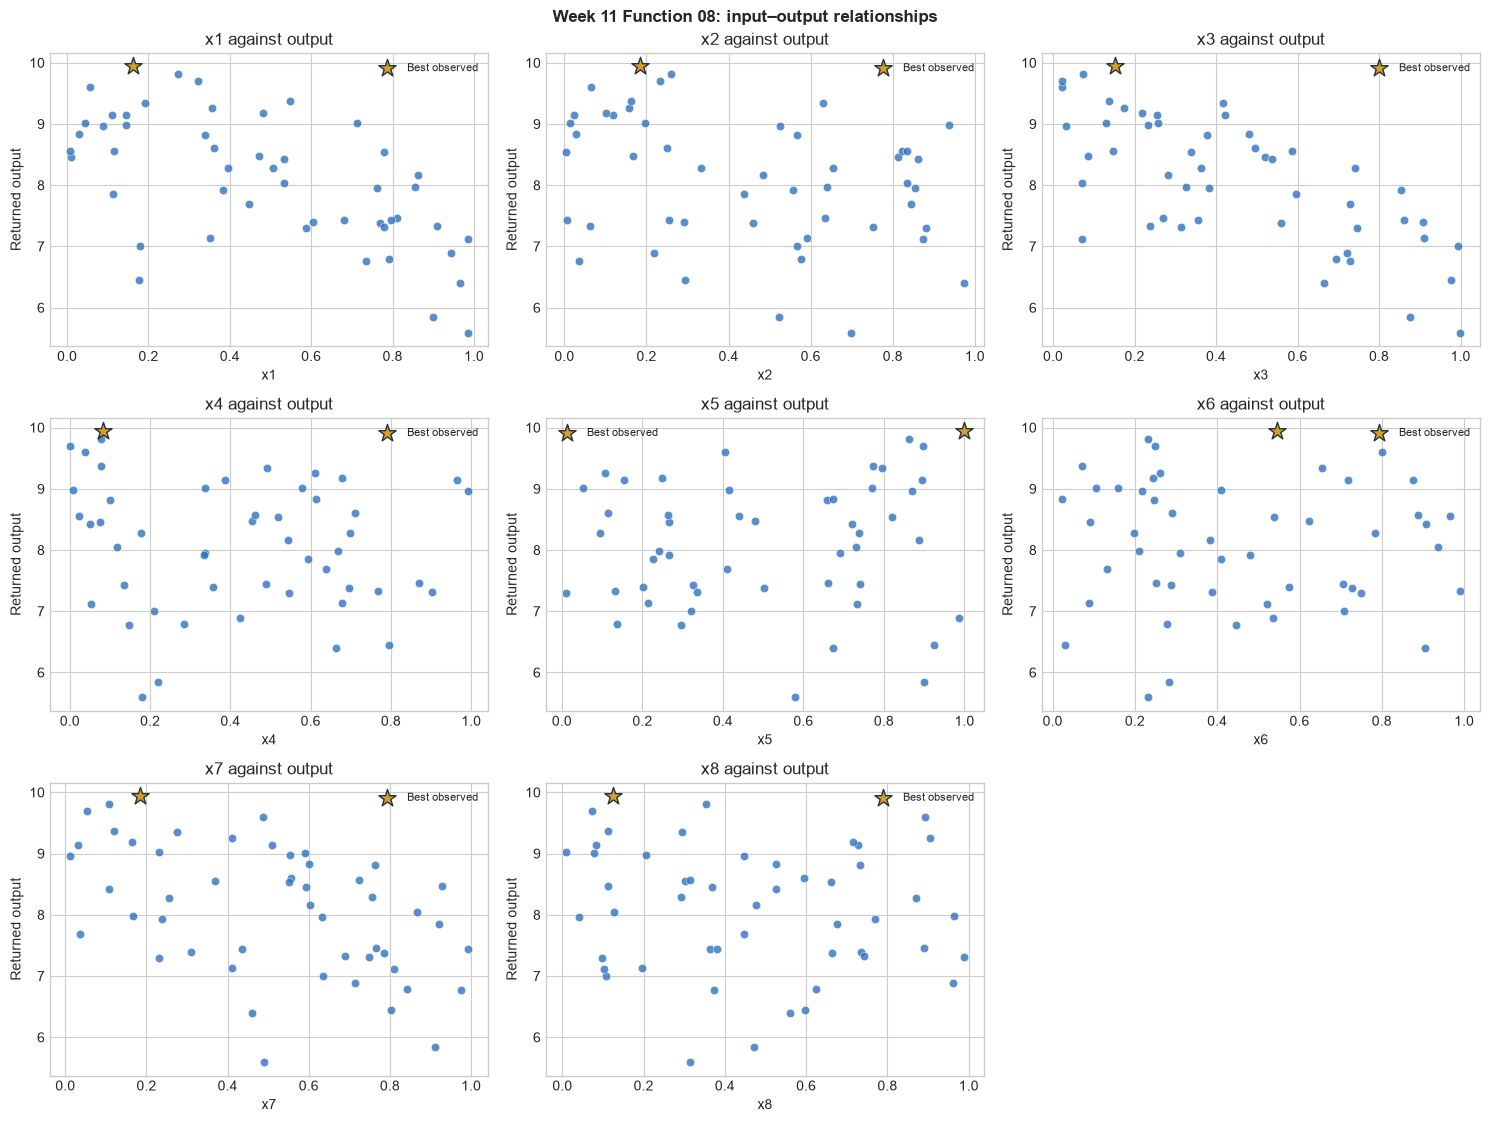

In [94]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [95]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 3.45**2 * Matern(length_scale=[3.28, 5.22, 2.72, 4.77, 10, 4.72, 3.41, 10], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [96]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_8:0.160619-0.130319-0.239413-0.161056-0.744457-0.544413-0.213243-0.709643


,week,function,kappa,x1,x2,x3,x4,x5,x6,x7,x8,predicted_mean,predicted_std,ucb_score,status
0,11,8,2.0,0.160619,0.130319,0.239413,0.161056,0.744457,0.544413,0.213243,0.709643,9.950462,0.048782,10.048026,proposed_not_evaluated
